In [19]:
import os, numpy as np, pandas as pd
from scipy.signal import butter, filtfilt, iirnotch, welch
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import FastICA
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import GradientBoostingClassifier
import antropy as ant
from sklearn.decomposition import PCA, FastICA
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from sklearn.linear_model import RidgeClassifier
from sklearn.ensemble import AdaBoostClassifier, ExtraTreesClassifier, BaggingClassifier
from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB
from lightgbm import LGBMClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
from sklearn.multiclass import OneVsRestClassifier

In [20]:
fs = 256
window_sec = 2
window_samples = int(window_sec * fs)
lowcut = 1.0
highcut = 40.0
notch_freq = 50.0
notch_quality = 30.0
channel_cols = ['Fp1','Fp2','F3','F4','C3','C4','P3','P4','O1','O2','F7','F8','T7','T8','P7','P8','Fz','Cz','Pz']

In [21]:
data = pd.read_csv("C:/Users/USER/adhdata.csv")
print(data.shape)
print(data.head())


(2166383, 21)
     Fp1    Fp2     F3     F4     C3     C4     P3     P4     O1     O2  ...  \
0  261.0  402.0   16.0  261.0  126.0  384.0  126.0  236.0   52.0  236.0  ...   
1  121.0  191.0  -94.0   85.0   16.0  200.0  126.0   52.0  347.0  273.0  ...   
2  -55.0   85.0 -204.0   15.0  -57.0  200.0   52.0  126.0  236.0  200.0  ...   
3  191.0   85.0   52.0   50.0   89.0  236.0  163.0   89.0   89.0   89.0  ...   
4  -55.0 -125.0 -204.0 -160.0 -204.0   16.0 -241.0 -241.0   89.0   16.0  ...   

      F8     T7     T8     P7     P8     Fz     Cz     Pz  Class    ID  
0   16.0  200.0  494.0  126.0  236.0  121.0  367.0  121.0   ADHD  v10p  
1  -57.0  126.0  347.0   52.0   52.0   15.0  121.0  -19.0   ADHD  v10p  
2  -94.0  126.0  420.0   52.0  126.0  -55.0  261.0   85.0   ADHD  v10p  
3  -57.0  236.0  420.0  126.0  126.0   15.0   85.0  -55.0   ADHD  v10p  
4 -131.0   89.0  310.0  -57.0   52.0  -55.0   15.0 -336.0   ADHD  v10p  

[5 rows x 21 columns]


In [22]:
# =========================
# 3. Define Filters
# =========================
def bandpass_filter(signal, lowcut, highcut, fs, order=5):
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    b, a = butter(order, [low, high], btype='band')
    return filtfilt(b, a, signal)

def notch_filter(signal, notch_freq, fs, quality=30):
    b, a = iirnotch(notch_freq, quality, fs)
    return filtfilt(b, a, signal)



In [23]:
def extract_features(window, fs):
    """Extract bandpower + nonlinear EEG features from one channel window."""
    window = np.asarray(window, dtype=np.float64).ravel().copy()
    features = []
    
    # 1. Bandpower (delta, theta, alpha, beta, gamma)
    freqs, psd = welch(window, fs=fs, nperseg=fs*2)
    bands = {
        'delta': (0.5, 4),
        'theta': (4, 8),
        'alpha': (8, 13),
        'beta':  (13, 30),
        'gamma': (30, 40)
    }
    for (low, high) in bands.values():
        idx = np.logical_and(freqs >= low, freqs <= high)
        features.append(np.trapz(psd[idx], freqs[idx]))
    
    # 2. Fractal / Complexity Features
    features.append(ant.katz_fd(window))             # Katz FD
    features.append(ant.petrosian_fd(window))        # Petrosian FD
    
    try:
        features.append(ant.higuchi_fd(window, kmax=10))   # Higuchi FD
    except Exception:
        features.append(np.nan)
    
    features.append(ant.detrended_fluctuation(window))     # DFA
    
    # ---- FIX for LZC ----
    # Discretize into 0/1 sequence before computing LZC
    bins = np.median(window)     # threshold
    seq = (window > bins).astype(int)
    
    try:
        features.append(ant.lziv_complexity(seq, normalize=True))
    except Exception:
        features.append(np.nan)
    
    return features


In [24]:
# =========================
# 5. Preprocessing + ICA + Feature Extraction
# =========================
X, y, subject_ids = [], [], []

for subject, df_sub in data.groupby("ID"):
    eeg_data = df_sub[channel_cols].values
    labels = df_sub["Class"].values
    
    # Step 1: Filtering
    for ch in range(eeg_data.shape[1]):
        eeg_data[:, ch] = notch_filter(eeg_data[:, ch], notch_freq, fs)
        eeg_data[:, ch] = bandpass_filter(eeg_data[:, ch], lowcut, highcut, fs)
    
    # Step 2: Standardize before ICA
    eeg_data = (eeg_data - eeg_data.mean(axis=0)) / eeg_data.std(axis=0)
    
    # Step 3: ICA
    ica = FastICA(
        n_components=min(15, eeg_data.shape[1]),
        random_state=42,
        max_iter=10000,
        tol=0.01
    )
    sources = ica.fit_transform(eeg_data)
    reconstructed = ica.inverse_transform(sources)
    
    # Step 4: Windowing + Feature Extraction
    for start in range(0, len(reconstructed) - window_samples, window_samples):
        window = reconstructed[start:start+window_samples, :]
        feats = []
        for ch in range(window.shape[1]):
            feats.extend(extract_features(window[:, ch], fs))
        X.append(feats)
        y.append(labels[start])
        subject_ids.append(subject)

X = np.array(X)
y = np.array(y)
print("Feature matrix shape:", X.shape)

C:\Users\USER\miniconda3\envs\py_gpu\lib\site-packages\sklearn\decomposition\_fastica.py:127: ConvergenceWarning: FastICA did not converge. Consider increasing tolerance or the maximum number of iterations.
  warnings.warn(


Feature matrix shape: (4172, 190)


In [25]:
le = LabelEncoder()
y_enc = le.fit_transform(y)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print("Classes:", le.classes_)

Classes: ['ADHD' 'Control']


In [26]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_enc, test_size=0.2, stratify=y_enc, random_state=42
)

In [27]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# -----------------------------
# Define models with optimized hyperparameters where applicable
models = {
    # Linear models
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Ridge Classifier": RidgeClassifier(),

    # KNN & SVM
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "SVM": SVC(kernel='rbf', probability=True),

    # Ensemble methods
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=300, learning_rate=0.05, max_depth=5, random_state=42),
    "AdaBoost": AdaBoostClassifier(n_estimators=200, learning_rate=0.1, random_state=42),
    "Extra Trees": ExtraTreesClassifier(n_estimators=200, max_depth=10, random_state=42),
    "Bagging": BaggingClassifier(n_estimators=50, random_state=42),

    # Gradient boosting libraries with optimized parameters
    "XGBoost": XGBClassifier(n_estimators=300, learning_rate=0.05, max_depth=5, use_label_encoder=False, eval_metric='mlogloss', random_state=42),
    

    # Probabilistic models
    "Gaussian NB": GaussianNB()
}

# -----------------------------
# Train & evaluate
results = {}
for name, model in models.items():
    # Use scaled data for distance-based models
    if name in ["KNN", "SVM"]:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
    
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc
    print(f"{name} Accuracy: {acc:.4f}")
    # Optional: print classification report for detailed metrics
    # print(f"\nClassification Report for {name}:\n", classification_report(y_test, y_pred))

# -----------------------------
# Print accuracies sorted
print("\nModel Accuracies on EEG Dataset (ranked):")
for model_name, accuracy in sorted(results.items(), key=lambda x: x[1], reverse=True):
    print(f"{model_name:20s}: {accuracy:.4f}")

Logistic Regression Accuracy: 0.7569
Ridge Classifier Accuracy: 0.7461
KNN Accuracy: 0.9030
SVM Accuracy: 0.8503
Decision Tree Accuracy: 0.7377
Random Forest Accuracy: 0.8395
Gradient Boosting Accuracy: 0.9269
AdaBoost Accuracy: 0.7006
Extra Trees Accuracy: 0.7641
Bagging Accuracy: 0.8826


C:\Users\USER\miniconda3\envs\py_gpu\lib\site-packages\xgboost\training.py:183: UserWarning: [12:29:29] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost Accuracy: 0.9281
Gaussian NB Accuracy: 0.5102

Model Accuracies on EEG Dataset (ranked):
XGBoost             : 0.9281
Gradient Boosting   : 0.9269
KNN                 : 0.9030
Bagging             : 0.8826
SVM                 : 0.8503
Random Forest       : 0.8395
Extra Trees         : 0.7641
Logistic Regression : 0.7569
Ridge Classifier    : 0.7461
Decision Tree       : 0.7377
AdaBoost            : 0.7006
Gaussian NB         : 0.5102


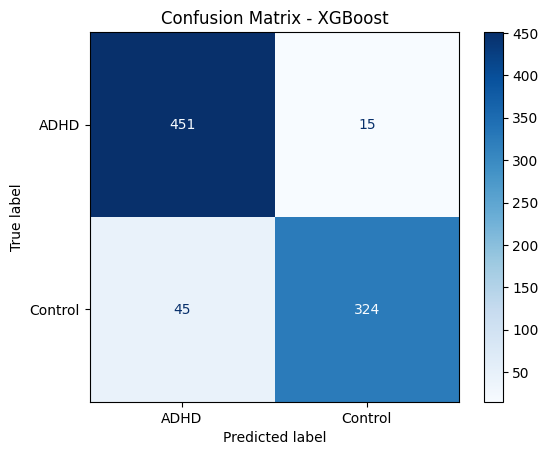

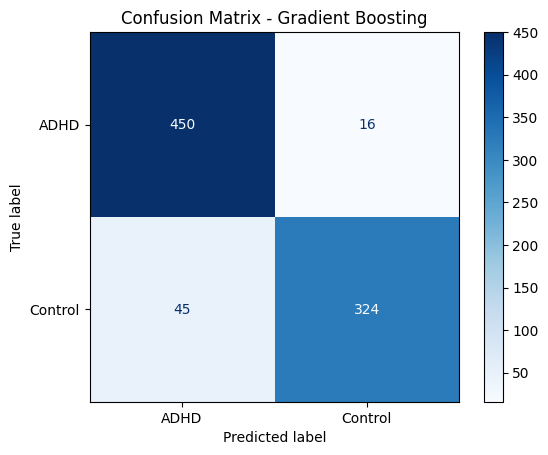

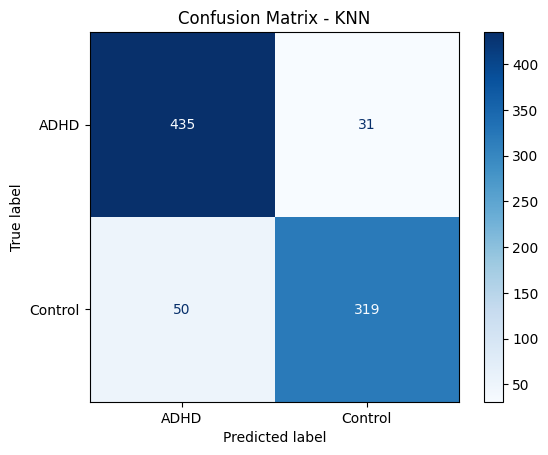

In [28]:
top3_models = ["XGBoost", "Gradient Boosting", "KNN"]

for model_name in top3_models:
    model = models[model_name]
    
    # Predict with appropriate input (scaled for KNN)
    if model_name in ["KNN"]:
        y_pred = model.predict(X_test_scaled)
    else:
        y_pred = model.predict(X_test)
    
    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
    disp.plot(cmap="Blues", values_format="d")
    plt.title(f"Confusion Matrix - {model_name}")
    plt.show()

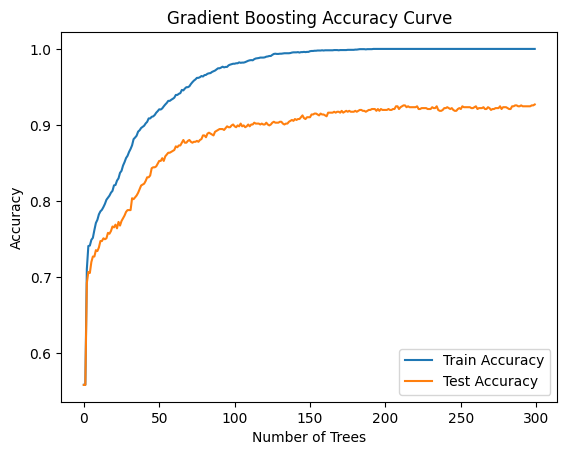

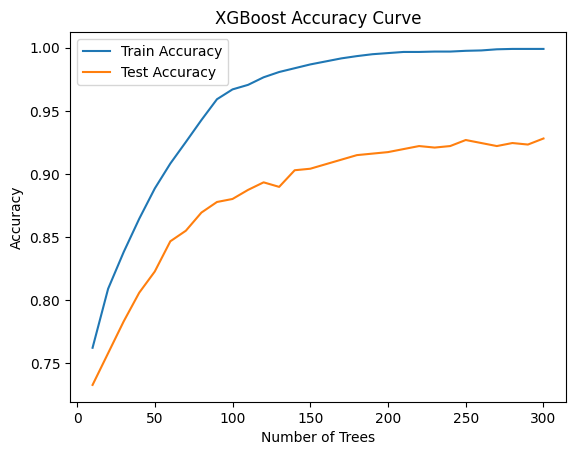

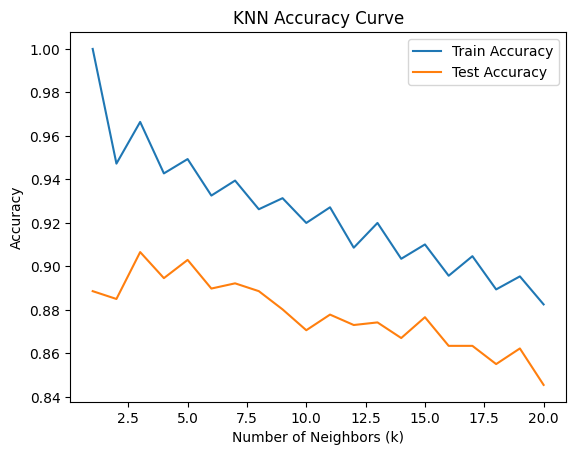

In [29]:
# Gradient Boosting Accuracy Curve
gb = GradientBoostingClassifier(
    n_estimators=300, learning_rate=0.05, max_depth=5, random_state=42
)
gb.fit(X_train, y_train)

train_acc_gb, test_acc_gb = [], []
for y_tr, y_te in zip(gb.staged_predict(X_train), gb.staged_predict(X_test)):
    train_acc_gb.append(accuracy_score(y_train, y_tr))
    test_acc_gb.append(accuracy_score(y_test, y_te))

plt.figure()
plt.plot(train_acc_gb, label="Train Accuracy")
plt.plot(test_acc_gb, label="Test Accuracy")
plt.title("Gradient Boosting Accuracy Curve")
plt.xlabel("Number of Trees")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

# -----------------------------
# XGBoost Accuracy Curve
train_acc_xgb, test_acc_xgb = [], []
for n in range(10, 310, 10):  # step by 10 trees
    xgb_tmp = XGBClassifier(
        n_estimators=n, learning_rate=0.05, max_depth=5,
        eval_metric="mlogloss", random_state=42
    )
    xgb_tmp.fit(X_train, y_train)
    train_acc_xgb.append(accuracy_score(y_train, xgb_tmp.predict(X_train)))
    test_acc_xgb.append(accuracy_score(y_test, xgb_tmp.predict(X_test)))

plt.figure()
plt.plot(range(10, 310, 10), train_acc_xgb, label="Train Accuracy")
plt.plot(range(10, 310, 10), test_acc_xgb, label="Test Accuracy")
plt.title("XGBoost Accuracy Curve")
plt.xlabel("Number of Trees")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

# -----------------------------
# KNN Accuracy Curve (train/test accuracy vs k)
train_acc_knn, test_acc_knn = [], []
neighbors = range(1, 21)

for k in neighbors:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    train_acc_knn.append(accuracy_score(y_train, knn.predict(X_train_scaled)))
    test_acc_knn.append(accuracy_score(y_test, knn.predict(X_test_scaled)))

plt.figure()
plt.plot(neighbors, train_acc_knn, label="Train Accuracy")
plt.plot(neighbors, test_acc_knn, label="Test Accuracy")
plt.title("KNN Accuracy Curve")
plt.xlabel("Number of Neighbors (k)")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

XGBoost: y_test_bin=(835, 1), y_score=(835, 2)


C:\Users\USER\miniconda3\envs\py_gpu\lib\site-packages\sklearn\metrics\_ranking.py:1201: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(


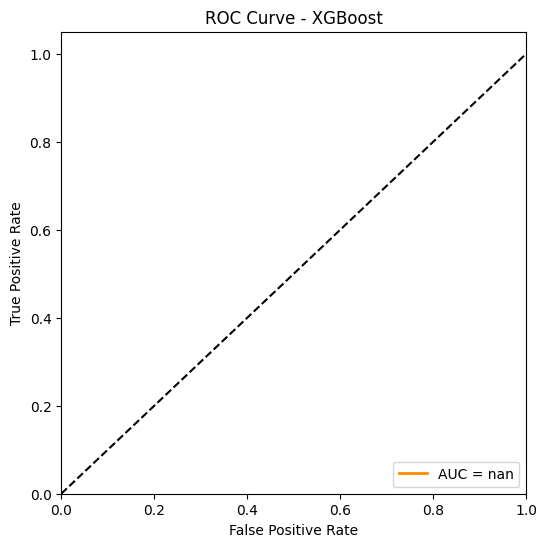

Gradient Boosting: y_test_bin=(835, 1), y_score=(835, 2)


C:\Users\USER\miniconda3\envs\py_gpu\lib\site-packages\sklearn\metrics\_ranking.py:1201: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(


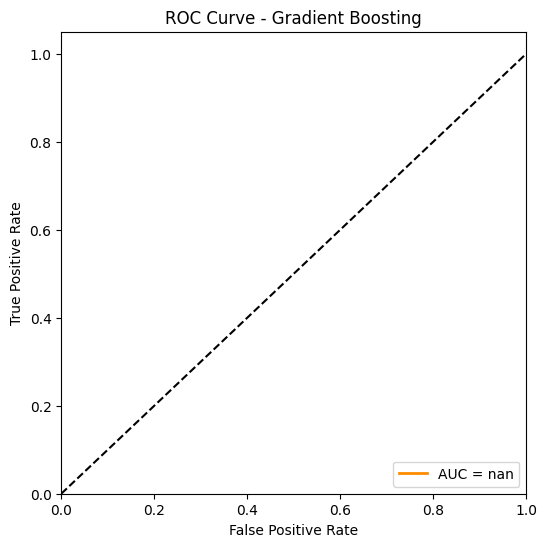

KNN: y_test_bin=(835, 1), y_score=(835, 2)


C:\Users\USER\miniconda3\envs\py_gpu\lib\site-packages\sklearn\metrics\_ranking.py:1201: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(


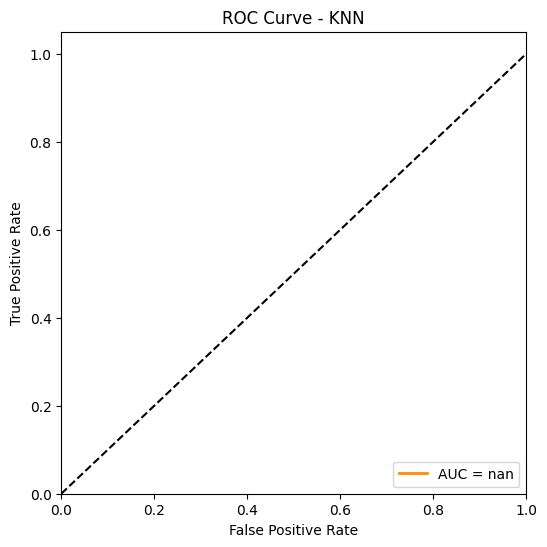

In [32]:
classes = np.unique(y)
n_classes = len(classes)

def plot_roc_curve(model, X_test, y_test, name, scaled=False):
    # Scale features if needed
    if scaled:
        X_used = scaler.transform(X_test)
    else:
        X_used = X_test

    # Get probabilities
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_used)
    else:
        y_score = model.decision_function(X_used)

    # If binary classification → ensure shape (n_samples, 2)
    if n_classes == 2:
        if y_score.ndim == 1:  # decision_function outputs (n_samples,)
            y_score = np.vstack([1 - y_score, y_score]).T
        elif y_score.shape[1] == 1:  # Only one column predicted
            y_score = np.hstack([1 - y_score, y_score])

    # Binarize labels
    y_test_bin = label_binarize(y_test, classes=classes)

    # Debug shapes
    print(f"{name}: y_test_bin={y_test_bin.shape}, y_score={y_score.shape}")

    fpr, tpr, roc_auc = {}, {}, {}

    if n_classes == 2:
        # Binary ROC (use positive class column)
        fpr[1], tpr[1], _ = roc_curve(y_test_bin.ravel(), y_score[:, 1])
        roc_auc[1] = auc(fpr[1], tpr[1])

        # Plot
        plt.figure(figsize=(6, 6))
        plt.plot(fpr[1], tpr[1], color="darkorange",
                 lw=2, label=f"AUC = {roc_auc[1]:.2f}")
        plt.plot([0, 1], [0, 1], "k--")
        plt.xlim([0.0, 1.0])
        plt.ylim([0.0, 1.05])
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.title(f"ROC Curve - {name}")
        plt.legend(loc="lower right")
        plt.show()

    else:
        # Multiclass case
        for i in range(n_classes):
            fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
            roc_auc[i] = auc(fpr[i], tpr[i])

        # Micro-average ROC
        fpr["micro"], tpr["micro"], _ = roc_curve(y_test_bin.ravel(), y_score.ravel())
        roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

        # Plot
        plt.figure(figsize=(6, 6))
        plt.plot(fpr["micro"], tpr["micro"],
                 label=f'Micro-average (AUC = {roc_auc["micro"]:.2f})',
                 color='deeppink', linestyle=':', linewidth=3)

        for i in range(n_classes):
            plt.plot(fpr[i], tpr[i], lw=2, label=f'Class {i} (AUC = {roc_auc[i]:.2f})')

        plt.plot([0, 1], [0, 1], 'k--')
        plt.xlim([0.0, 1.0])
        plt.ylim([0.0, 1.05])
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title(f'ROC Curve - {name}')
        plt.legend(loc="lower right")
        plt.show()


# Run for your top 3
plot_roc_curve(models["XGBoost"], X_test, y_test, "XGBoost")
plot_roc_curve(models["Gradient Boosting"], X_test, y_test, "Gradient Boosting")
plot_roc_curve(models["KNN"], X_test, y_test, "KNN", scaled=True)